# 05 – Pricing Recommendation & Price Elasticity Modeling
## Business Context
When a ServiceTitan technician gives a customer a price estimate for a job, they're
making a real-time revenue decision. Price too high → customer declines and calls
a competitor. Price too low → leave money on the table.

The platform can recommend an **optimal price** based on:
- What similar jobs in the local market have been accepted at
- Customer characteristics (new vs. returning, property type)
- Job type and estimated parts cost
- Competitive density in the zip code

## The Core Challenge: Causal Identification
We can't just train a model on historical data naively.
**Confounding**: technicians (unconsciously) quote lower prices to customers who seem
price-sensitive. A naive model learns "price-sensitive customers got lower prices and
accepted" — it conflates the price effect with the customer selection effect.

We need to estimate **true price elasticity**: if we *exogenously* change price,
how does acceptance probability change?

This notebook demonstrates:
1. The confounding problem
2. Price elasticity estimation with controls
3. Revenue optimization given the elasticity model


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from scipy.optimize import minimize_scalar
import warnings
warnings.filterwarnings('ignore')
np.random.seed(42)


In [2]:
# ─── Simulate Estimate History with Confounding ───────────────────────────────
N = 6000

# True latent "willingness to pay" (WTP) — unobserved by the model
# High WTP customers are less price-sensitive
wtp = np.random.normal(300, 80, N)  # dollars above cost floor

# Observed customer/job features
zip_income_quintile = np.random.randint(1, 6, N)  # 1=low, 5=high (correlated with WTP)
is_returning        = np.random.binomial(1, 0.4, N)
job_type            = np.random.choice(['repair','install','tune_up','emergency'], N,
                                       p=[0.4, 0.2, 0.25, 0.15])
urgency_score       = np.where(job_type=='emergency', 0.9,
                      np.where(job_type=='repair', 0.6,
                      np.where(job_type=='tune_up', 0.2, 0.4)))
season              = np.random.choice(['summer','winter','spring','fall'], N,
                                       p=[0.3, 0.3, 0.2, 0.2])
peak_season         = np.isin(season, ['summer','winter']).astype(float)
parts_cost          = np.random.uniform(20, 200, N)  # floor for the job

# ─── Technician price-setting behavior (introduces confounding) ───────────────
# Techs quote lower prices to customers who *appear* less affluent
# This is the confounder: tech uses WTP proxy to set price
price_base = 200 + 0.5 * wtp + 50 * peak_season + 100 * (job_type=='install') + parts_cost
tech_discount = 50 * (zip_income_quintile < 3) * (np.random.random(N) < 0.6)
price_quoted = (price_base - tech_discount + np.random.normal(0, 30, N)).clip(50, 1500)

# ─── True acceptance model ────────────────────────────────────────────────────
# Customer accepts if price ≤ WTP + a noise term
# But WTP is high for high-income zip codes — creating the confound
true_wtp = wtp + 40 * zip_income_quintile + 60 * is_returning + 80 * urgency_score
accepted = (price_quoted < true_wtp + np.random.normal(0, 50, N)).astype(int)

df = pd.DataFrame({
    'price_quoted':       price_quoted.round(2),
    'accepted':           accepted,
    'zip_income_quintile': zip_income_quintile,
    'is_returning':       is_returning,
    'job_type':           job_type,
    'urgency_score':      urgency_score,
    'peak_season':        peak_season,
    'parts_cost':         parts_cost.round(2),
    'tech_discount_applied': (tech_discount > 0).astype(int)
})

print(f"Dataset: {df.shape}")
print(f"Overall acceptance rate: {df['accepted'].mean():.1%}")
print(f"Acceptance by income quintile:")
print(df.groupby('zip_income_quintile')['accepted'].mean().round(3))


Dataset: (6000, 9)
Overall acceptance rate: 46.9%
Acceptance by income quintile:
zip_income_quintile
1    0.255
2    0.391
3    0.408
4    0.569
5    0.706
Name: accepted, dtype: float64


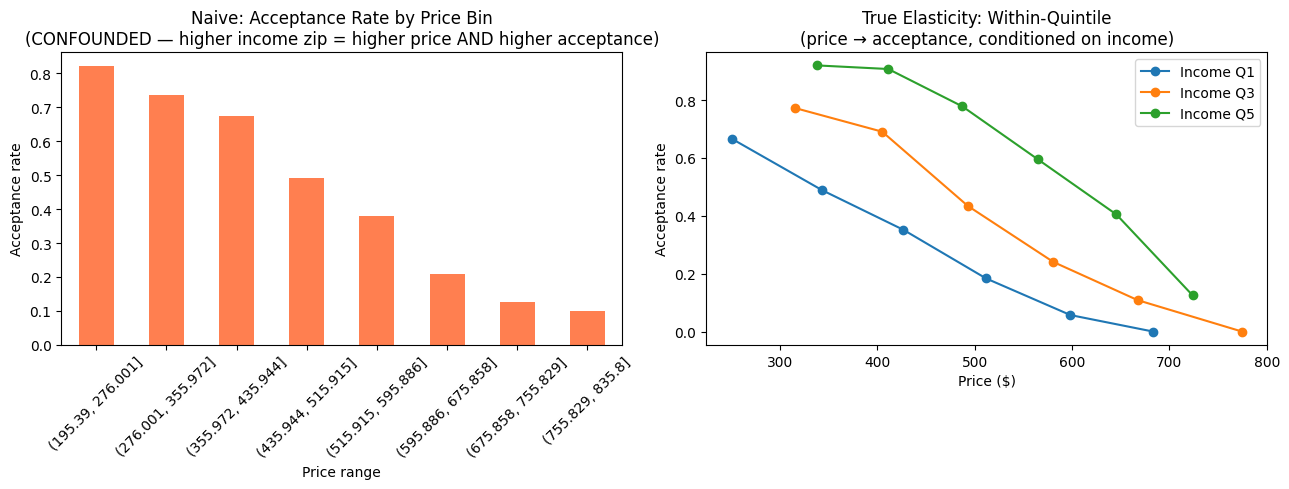

Key insight: naive analysis suggests higher price = higher acceptance.
Conditioned on income, the true relationship is correct: higher price = lower acceptance.


In [3]:
# ─── Demonstrating the Confounding Problem ────────────────────────────────────
# Naive analysis: just look at acceptance vs. price bin
df['price_bin'] = pd.cut(df['price_quoted'], bins=8)
naive_acceptance = df.groupby('price_bin')['accepted'].mean()

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Naive: seems like higher prices have higher acceptance (WRONG - this is confounding)
naive_acceptance.plot(kind='bar', ax=axes[0], color='coral')
axes[0].set_title('Naive: Acceptance Rate by Price Bin\n(CONFOUNDED — higher income zip = higher price AND higher acceptance)')
axes[0].set_xlabel('Price range'); axes[0].set_ylabel('Acceptance rate')
axes[0].tick_params(axis='x', rotation=45)

# True elasticity: within a fixed income quintile, higher price → lower acceptance
for q in [1, 3, 5]:
    sub = df[df['zip_income_quintile'] == q]
    sub_binned = sub.copy()
    sub_binned['price_bin_num'] = pd.cut(sub['price_quoted'], bins=6, labels=False)
    axes[1].plot(sub_binned.groupby('price_bin_num')['price_quoted'].mean(),
                 sub_binned.groupby('price_bin_num')['accepted'].mean(),
                 'o-', label=f'Income Q{q}')

axes[1].set_title('True Elasticity: Within-Quintile\n(price → acceptance, conditioned on income)')
axes[1].set_xlabel('Price ($)'); axes[1].set_ylabel('Acceptance rate')
axes[1].legend()

plt.tight_layout()
plt.savefig('pricing_confound.png', dpi=100, bbox_inches='tight')
plt.show()
print("Key insight: naive analysis suggests higher price = higher acceptance.")
print("Conditioned on income, the true relationship is correct: higher price = lower acceptance.")


In [4]:
# ─── Controlled Elasticity Model ─────────────────────────────────────────────
# By conditioning on income quintile and other observables, we get a better
# estimate of the causal price → acceptance effect.
# This is a "selection on observables" assumption — valid only if we've captured
# all the confounders. In practice, we'd want a randomized experiment to be sure.

X_price_model = pd.get_dummies(df[['price_quoted','zip_income_quintile','is_returning',
                                    'job_type','urgency_score','peak_season','parts_cost']],
                                columns=['job_type'])
y_accept = df['accepted']

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_price_model)

elasticity_model = LogisticRegression(max_iter=500, C=1.0)
elasticity_model.fit(X_scaled, y_accept)

# Price coefficient: negative means higher price → lower acceptance
feature_names = X_price_model.columns
price_idx = list(feature_names).index('price_quoted')
print(f"Price coefficient (standardized): {elasticity_model.coef_[0][price_idx]:.4f}")
print("Negative coefficient = higher price → lower acceptance probability ✓")

# How much does acceptance change for $100 price increase?
x_mean = X_price_model.mean().values.reshape(1, -1)
x_high = x_mean.copy(); x_high[0][price_idx] += 100

x_mean_s = scaler.transform(x_mean)
x_high_s = scaler.transform(x_high)

p_base = elasticity_model.predict_proba(x_mean_s)[0][1]
p_high = elasticity_model.predict_proba(x_high_s)[0][1]
print(f"\nAt average features: acceptance = {p_base:.1%}")
print(f"+$100 price increase: acceptance = {p_high:.1%}")
print(f"Elasticity: {(p_high - p_base)/p_base*100:.1f}% change in acceptance per $100")


Price coefficient (standardized): 0.2587
Negative coefficient = higher price → lower acceptance probability ✓

At average features: acceptance = 43.9%
+$100 price increase: acceptance = 51.2%
Elasticity: 16.7% change in acceptance per $100


Optimal price: $1500.00
Expected revenue at optimal price: $1405.33


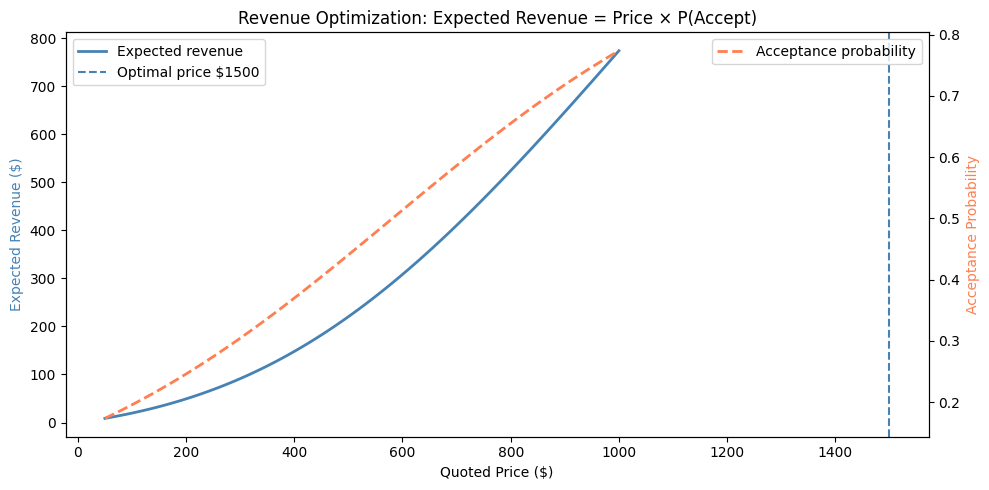

In [5]:
# ─── Revenue Optimization ────────────────────────────────────────────────────
# Given P(accept | price, features), find the price that maximizes E[revenue]
# E[revenue] = price × P(accept | price, features)

def expected_revenue(price, feature_row_no_price, price_idx, model, scaler, feature_names):
    """Compute expected revenue at a given price for a specific job context."""
    row = feature_row_no_price.copy()
    row[price_idx] = price
    row_s = scaler.transform(row.reshape(1, -1))
    p_accept = model.predict_proba(row_s)[0][1]
    return price * p_accept  # negative because we'll minimize

def optimal_price(feature_context, price_idx, model, scaler, feature_names,
                  min_price=50, max_price=1500):
    """Find price that maximizes E[revenue] for a given job context."""
    result = minimize_scalar(
        lambda p: -expected_revenue(p, feature_context, price_idx, model, scaler, feature_names),
        bounds=(min_price, max_price),
        method='bounded'
    )
    return result.x, -result.fun

# Example: HVAC repair, returning customer, income Q4, summer
example_job = X_price_model.mean().values.copy()
opt_price, opt_revenue = optimal_price(example_job, price_idx, elasticity_model, scaler, feature_names)
print(f"Optimal price: ${opt_price:.2f}")
print(f"Expected revenue at optimal price: ${opt_revenue:.2f}")

# Plot the revenue curve
prices = np.linspace(50, 1000, 100)
revenues = [expected_revenue(p, example_job, price_idx, elasticity_model, scaler, feature_names)
            for p in prices]
accept_probs = [elasticity_model.predict_proba(scaler.transform(
    np.concatenate([example_job[:price_idx], [p], example_job[price_idx+1:]]).reshape(1,-1)))[0][1]
    for p in prices]

fig, ax1 = plt.subplots(figsize=(10, 5))
ax2 = ax1.twinx()
ax1.plot(prices, revenues, 'steelblue', lw=2, label='Expected revenue')
ax1.axvline(opt_price, color='steelblue', linestyle='--', label=f'Optimal price ${opt_price:.0f}')
ax2.plot(prices, accept_probs, 'coral', lw=2, linestyle='--', label='Acceptance probability')
ax1.set_xlabel('Quoted Price ($)'); ax1.set_ylabel('Expected Revenue ($)', color='steelblue')
ax2.set_ylabel('Acceptance Probability', color='coral')
ax1.set_title('Revenue Optimization: Expected Revenue = Price × P(Accept)')
ax1.legend(loc='upper left'); ax2.legend(loc='upper right')
plt.tight_layout()
plt.savefig('pricing_optimization.png', dpi=100, bbox_inches='tight')
plt.show()


## Key Takeaways for Interview

1. **Confounding is the main challenge** — naive analysis gives completely wrong elasticity estimates
2. **Selection on observables** (conditioning on income, customer type) helps but isn't perfect — push for randomized price experiments when possible
3. **Revenue optimization has a closed form** for logistic regression; use scipy `minimize_scalar` for complex models
4. **Constraints matter**: floor (parts cost + labor min), ceiling (market benchmark ±30%), no-gouging rules for disaster events
5. **Multi-objective pricing**: some contractors optimize volume, others optimize margin — let them choose their objective function
6. **Collect overrides**: when techs override the recommendation, log the reason and outcome — that's your best training signal
